# EDA Precision Report — Student Performance Analysis

## Introduction

This notebook presents a complete exploratory data analysis of a student performance dataset. The analysis focuses on identifying genuine relationships between numerical variables, comparing exam performance across class sections, and validating visual findings with appropriate statistical methods.

The analysis is designed to distinguish relationships from categorical comparisons, quantify associations rather than relying only on visual impressions, and support comparison claims with uncertainty estimates. Particular attention is given to reporting null findings honestly, distinguishing correlation from causation, and verifying that every numerical claim in the report is supported by a fresh computation.

The notebook follows a structured workflow from dataset diagnosis through relationship analysis, statistical validation, visual quality assurance, self-audit, and final interpretation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from IPython.display import Markdown, display
from pathlib import Path

In [2]:
output_dir = Path("eda_outputs")
output_dir.mkdir(exist_ok=True)

## 1. Dataset Generation

The analysis uses the student performance dataset provided for this exercise. The dataset is intentionally generated from a fixed specification so that the relationships examined later in the analysis can be evaluated consistently.

The generation logic is kept exactly as provided. A fixed random seed is used to make the dataset reproducible, while the generated variables represent study time, sleep, attendance, class section, and exam performance.

In [3]:
rng = np.random.default_rng(seed=21)

n = 600

class_section = rng.choice(
    ["A", "B", "C"],
    size=n,
    p=[0.34, 0.33, 0.33]
)

study_hours = (
    rng.normal(10, 3.5, size=n)
    .clip(0, None)
    .round(1)
)

sleep_hours = (
    rng.normal(7, 1.2, size=n)
    .clip(3, 10)
    .round(1)
)

attendance_pct = (
    rng.normal(85, 10, size=n)
    .clip(40, 100)
    .round(1)
)

noise = rng.normal(0, 8, size=n)

section_bonus = (
    pd.Series(class_section)
    .map({"A": 0, "B": 0, "C": 4})
    .values
)

exam_score = (
    50
    + 2.6 * study_hours
    + 0.15 * attendance_pct
    + section_bonus
    + noise
).clip(0, 100).round(1)

students = pd.DataFrame({
    "student_id": np.arange(1, n + 1),
    "class_section": class_section,
    "study_hours_per_week": study_hours,
    "sleep_hours_per_night": sleep_hours,
    "attendance_pct": attendance_pct,
    "exam_score": exam_score,
})

### Initial Inspection

Before analyzing relationships or differences between groups, the generated dataset is inspected to confirm its structure and contents. This establishes the starting point for the analysis and helps ensure that later findings are based on the expected variables and data types.

In [4]:
students.head()

,student_id,class_section,study_hours_per_week,sleep_hours_per_night,attendance_pct,exam_score
0,1,C,11.0,7.3,89.4,100.0
1,2,B,9.1,7.7,72.4,72.2
2,3,C,2.2,8.5,84.6,67.2
3,4,A,13.5,7.5,83.4,100.0
4,5,B,11.0,5.4,100.0,100.0


In [5]:
students.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             600 non-null    int64  
 1   class_section          600 non-null    str    
 2   study_hours_per_week   600 non-null    float64
 3   sleep_hours_per_night  600 non-null    float64
 4   attendance_pct         600 non-null    float64
 5   exam_score             600 non-null    float64
dtypes: float64(4), int64(1), str(1)
memory usage: 28.3 KB


In [6]:
students.describe()

,student_id,study_hours_per_week,sleep_hours_per_night,attendance_pct,exam_score
count,600.000000,600.000000,600.000000,600.000000,600.000000
mean,300.500000,10.089333,7.046000,85.583000,88.605000
std,173.349358,3.407213,1.122787,9.137597,10.205279
min,1.000000,0.400000,3.400000,62.000000,58.900000
25%,150.750000,7.700000,6.275000,78.900000,81.750000
50%,300.500000,10.000000,7.100000,85.700000,90.200000
75%,450.250000,12.500000,7.800000,92.325000,98.700000
max,600.000000,21.900000,10.000000,100.000000,100.000000


In [7]:
row_count, column_count = students.shape

print(
    f"The generated dataset contains {row_count} rows and "
    f"{column_count} columns."
)

The generated dataset contains 600 rows and 6 columns.


## 2. Dataset Diagnosis

Before examining relationships or differences between groups, the dataset is
checked for structural and data-quality issues. These checks establish whether
the DataFrame has the expected dimensions, column types, missing values,
duplicate records, and categorical values.

Although this dataset is clean by construction, running these checks is an
important part of a reproducible EDA workflow. The purpose is not only to
identify problems when they exist, but also to verify the assumptions on which
the later analysis will depend.

### 2.1 Structure and Data Types

The first check examines the shape and data types of the dataset. This confirms
that the expected observations and variables are present and that numerical
measurements are represented using appropriate numeric types.

In [8]:
students.shape

(600, 6)

In [9]:
students.dtypes

student_id                 int64
class_section                str
study_hours_per_week     float64
sleep_hours_per_night    float64
attendance_pct           float64
exam_score               float64
dtype: object

In [10]:
structure_summary = pd.DataFrame({
    "column": students.columns,
    "dtype": students.dtypes.astype(str).values,
    "non_null_count": students.notna().sum().values
})

structure_summary

,column,dtype,non_null_count
0,student_id,int64,600
1,class_section,str,600
2,study_hours_per_week,float64,600
3,sleep_hours_per_night,float64,600
4,attendance_pct,float64,600
5,exam_score,float64,600


### 2.2 Missing Values

Missing values can affect both visualization and statistical calculations.
Before proceeding, the dataset is checked column by column so that later
relationships and comparisons are not unknowingly based on incomplete data.

In [11]:
missing_values = students.isna().sum()

missing_values

student_id               0
class_section            0
study_hours_per_week     0
sleep_hours_per_night    0
attendance_pct           0
exam_score               0
dtype: int64

In [12]:
total_missing = students.isna().sum().sum()

print(
    f"The dataset contains {total_missing} missing values across all columns."
)

The dataset contains 0 missing values across all columns.


### 2.3 Duplicate Records

Duplicate observations can cause some students to be represented more than
once and can distort descriptive statistics or relationships. The dataset is
therefore checked for completely duplicated rows before analysis continues.

In [13]:
duplicate_count = students.duplicated().sum()

print(
    f"The dataset contains {duplicate_count} fully duplicated rows."
)

The dataset contains 0 fully duplicated rows.


### 2.4 Class Section Values

The `class_section` variable will later be used to compare exam performance
between groups. Its observed categories are checked now to confirm that the
dataset contains the expected section labels and that no unexpected category
has entered the analysis.

In [14]:
students["class_section"].value_counts().sort_index()

class_section
A    212
B    198
C    190
Name: count, dtype: int64

In [15]:
section_count = students["class_section"].nunique()

print(
    f"The dataset contains {section_count} distinct class sections."
)

The dataset contains 3 distinct class sections.


### 2.5 Numerical Range Checks

The numerical variables are also checked against their intended ranges. Study
hours, sleep hours, attendance, and exam scores were generated with explicit
bounds, so these checks verify that the resulting data respects those
constraints before statistical analysis begins.

In [16]:
numeric_columns = [
    "study_hours_per_week",
    "sleep_hours_per_night",
    "attendance_pct",
    "exam_score",
]

range_check = students[numeric_columns].agg(["min", "max"]).T

range_check

,min,max
study_hours_per_week,0.4,21.9
sleep_hours_per_night,3.4,10.0
attendance_pct,62.0,100.0
exam_score,58.9,100.0


In [17]:
print(
    f"Diagnosis completed: {len(students)} observations were checked for "
    f"missing values, duplicates, categorical consistency, and numerical "
    f"ranges. The checks identified {total_missing} missing values and "
    f"{duplicate_count} fully duplicated rows."
)

Diagnosis completed: 600 observations were checked for missing values, duplicates, categorical consistency, and numerical ranges. The checks identified 0 missing values and 0 fully duplicated rows.


### Diagnosis Interpretation

The dataset is ready for exploratory analysis because the structural and
quality checks have been completed before examining relationships or group
differences. The next stage focuses on two relationship questions: whether
study hours are associated with exam performance and whether sleep hours show
a meaningful association with exam performance.

The second relationship is deliberately included even if the evidence is weak,
because a null result is still a valid finding and should be reported rather
than omitted.

## 3. Relationship Analysis

The first relationship examined is between weekly study hours and exam score.
The purpose is to determine whether students who report different amounts of
weekly study time also tend to have different exam scores.

Because both `study_hours_per_week` and `exam_score` are continuous numerical
variables, a scatter plot is appropriate for examining their relationship.
A fitted trend line is added to make the overall direction of the relationship
easier to assess visually.

The Pearson correlation coefficient is also calculated to quantify the strength
and direction of the linear association rather than relying only on the visual
pattern.

### 3.1 Study Hours vs. Exam Score

The scatter plot below compares weekly study hours with exam scores. Each point
represents one student, while the fitted trend line summarizes the overall
linear pattern in the data.

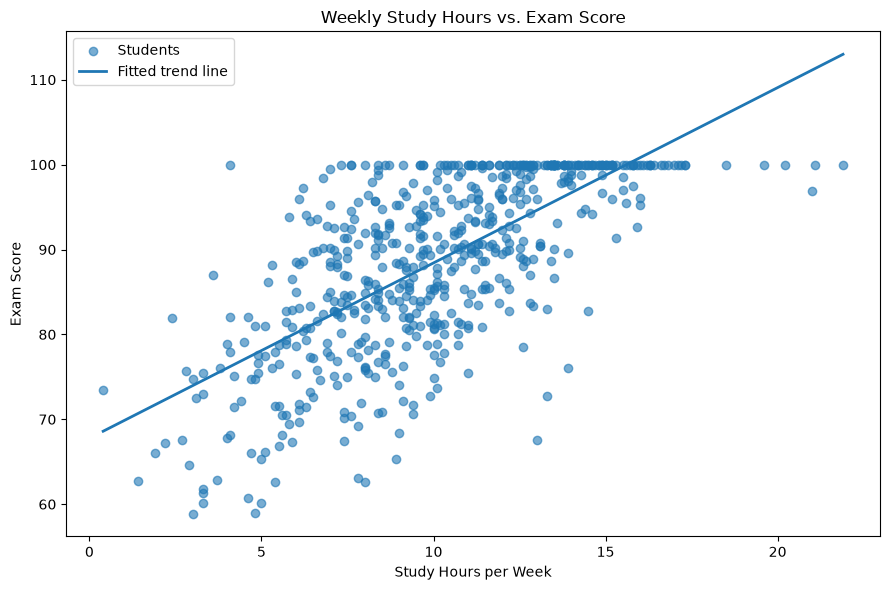

In [18]:
study_hours = students["study_hours_per_week"]

exam_scores = students["exam_score"]

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    study_hours,
    exam_scores,
    alpha=0.6,
    label="Students"
)

slope, intercept = np.polyfit(study_hours, exam_scores, 1)

x_line = np.linspace(
    study_hours.min(),
    study_hours.max(),
    100
)

y_line = slope * x_line + intercept

ax.plot(
    x_line,
    y_line,
    linewidth=2,
    label="Fitted trend line"
)

ax.set_title("Weekly Study Hours vs. Exam Score")

ax.set_xlabel("Study Hours per Week")

ax.set_ylabel("Exam Score")

ax.legend()

fig.tight_layout()

chart_path = output_dir / "study_hours_vs_exam_score.png"

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
study_exam_r = students["study_hours_per_week"].corr(
    students["exam_score"]
)

study_exam_r

np.float64(0.6894760997347233)

In [20]:
study_exam_r_check, study_exam_p_value = stats.pearsonr(
    students["study_hours_per_week"],
    students["exam_score"]
)

study_exam_r_check

np.float64(0.689476099734723)

In [21]:

finding_kata2 = f"""
### 3.1.1 Finding

The Pearson correlation between weekly study hours and exam score is
**{study_exam_r:.6f}**, indicating a positive linear relationship in this
dataset.

The scatter plot and fitted trend line visually support this result by showing
an overall upward pattern as weekly study hours increase.

The correlation was independently verified using `scipy.stats.pearsonr()`.
The primary calculation produced **{study_exam_r:.6f}**, while the
independent calculation produced **{study_exam_r_check:.6f}**.

The absolute difference between the two calculations was
**{abs(study_exam_r - study_exam_r_check):.12f}**.

This result indicates an association between study hours and exam score,
but correlation alone does not establish that increasing study hours
causes higher exam scores.
"""

display(Markdown(finding_kata2))


### 3.1.1 Finding

The Pearson correlation between weekly study hours and exam score is
**0.689476**, indicating a positive linear relationship in this
dataset.

The scatter plot and fitted trend line visually support this result by showing
an overall upward pattern as weekly study hours increase.

The correlation was independently verified using `scipy.stats.pearsonr()`.
The primary calculation produced **0.689476**, while the
independent calculation produced **0.689476**.

The absolute difference between the two calculations was
**0.000000000000**.

This result indicates an association between study hours and exam score,
but correlation alone does not establish that increasing study hours
causes higher exam scores.


### 3.2 Sleep Hours and Exam Score

The second relationship examines whether nightly sleep duration is associated
with exam performance. As with the previous analysis, both variables are
continuous numerical measurements, so a scatter plot is appropriate for
examining whether the variables move together.

The purpose of this analysis is also to identify a potentially null
relationship. A weak or near-zero correlation is still an important result:
it indicates that the two variables do not show a meaningful linear
association in this dataset and should therefore be reported rather than
treated as a failed analysis.

### 3.2.1 Sleep Hours vs. Exam Score

The scatter plot below compares nightly sleep hours with exam score. The
distribution of points provides the first visual indication of whether a
consistent linear pattern exists between the two variables.

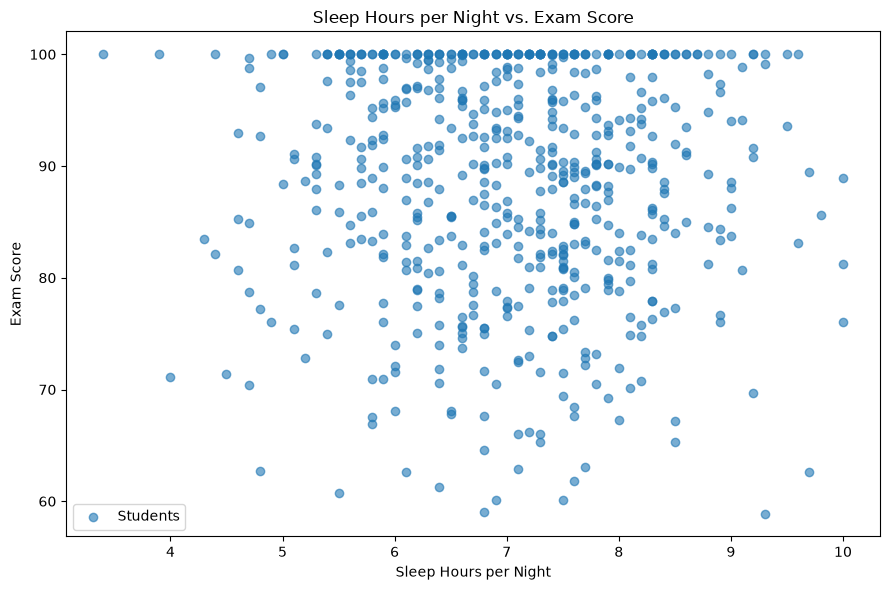

In [22]:
sleep_hours = students["sleep_hours_per_night"]

exam_scores = students["exam_score"]

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    sleep_hours,
    exam_scores,
    alpha=0.6,
    label="Students"
)

ax.set_title("Sleep Hours per Night vs. Exam Score")

ax.set_xlabel("Sleep Hours per Night")

ax.set_ylabel("Exam Score")

ax.legend()

fig.tight_layout()

chart_path = output_dir / "sleep_hours_vs_exam_score.png"

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
sleep_exam_r = students["sleep_hours_per_night"].corr(
    students["exam_score"]
)

sleep_exam_r

np.float64(-0.021657573452316673)

In [24]:
sleep_exam_r_check, sleep_exam_p_value = stats.pearsonr(
    students["sleep_hours_per_night"],
    students["exam_score"]
)

sleep_exam_r_check

np.float64(-0.021657573452316687)

In [25]:
finding_kata3 = f"""
### 3.2.2 Finding

The Pearson correlation between nightly sleep hours and exam score is
**{sleep_exam_r:.6f}**, indicating a near-zero linear relationship in this
dataset.

The scatter plot does not show a clear consistent upward or downward pattern,
which is consistent with the weak correlation observed in the calculation.

The correlation was independently verified using `scipy.stats.pearsonr()`.
The primary calculation produced **{sleep_exam_r:.6f}**, while the
independent calculation produced **{sleep_exam_r_check:.6f}**.

The absolute difference between the two calculations was
**{abs(sleep_exam_r - sleep_exam_r_check):.12f}**.

This near-zero correlation is a genuine finding rather than a failed analysis.
In this dataset, nightly sleep hours do not show a meaningful linear
association with exam score.
"""

display(Markdown(finding_kata3))


### 3.2.2 Finding

The Pearson correlation between nightly sleep hours and exam score is
**-0.021658**, indicating a near-zero linear relationship in this
dataset.

The scatter plot does not show a clear consistent upward or downward pattern,
which is consistent with the weak correlation observed in the calculation.

The correlation was independently verified using `scipy.stats.pearsonr()`.
The primary calculation produced **-0.021658**, while the
independent calculation produced **-0.021658**.

The absolute difference between the two calculations was
**0.000000000000**.

This near-zero correlation is a genuine finding rather than a failed analysis.
In this dataset, nightly sleep hours do not show a meaningful linear
association with exam score.


### 3.3 Exam Score by Class Section

The next analysis compares exam performance across the three class sections.
Unlike the previous analyses, this is a categorical comparison rather than a
relationship between two continuous numerical variables.

A comparison chart is appropriate because `class_section` consists of discrete
categories with no inherent numerical distance between them. The shuffle test
provides a direct way to identify this distinction: if the section labels were
reordered, the meaning of the comparison would remain unchanged. Therefore,
the position of A, B, and C on the x-axis does not represent a continuous
progression between sections.

### 3.3.1 Comparison of Exam Scores Across Sections

The mean exam score for each class section is displayed below. The sections
are kept in their natural A, B, C order rather than being sorted by their
observed scores, because the category labels themselves have a meaningful
organizational order in this dataset.

In [26]:
section_means = (
    students
    .groupby("class_section")["exam_score"]
    .mean()
    .reindex(["A", "B", "C"])
)

section_means

class_section
A    87.608491
B    87.025758
C    91.362632
Name: exam_score, dtype: float64

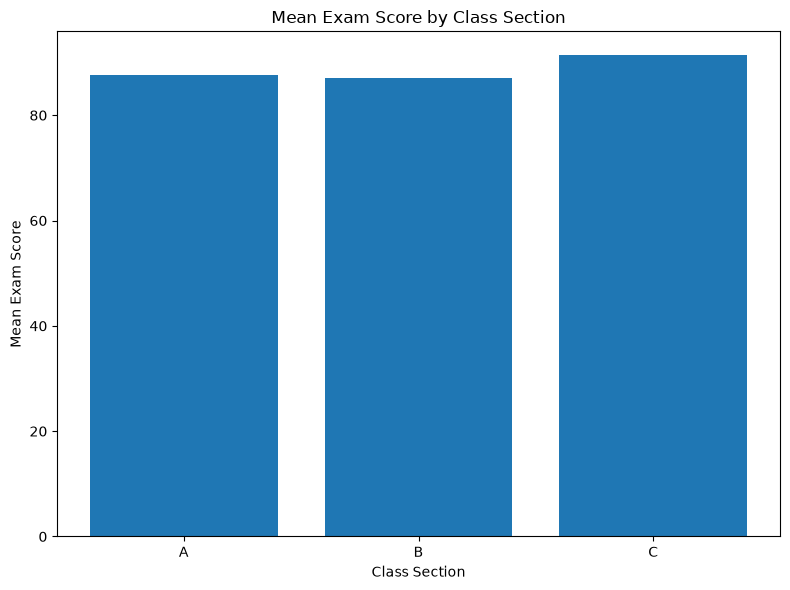

In [27]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.bar(
    section_means.index,
    section_means.values
)

ax.set_title("Mean Exam Score by Class Section")

ax.set_xlabel("Class Section")

ax.set_ylabel("Mean Exam Score")

fig.tight_layout()

chart_path = output_dir / "exam_score_by_class_section.png"

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
section_a_mean = section_means["A"]
section_b_mean = section_means["B"]
section_c_mean = section_means["C"]

finding_kata4 = f"""
### 3.3.2 Finding

The mean exam scores for Sections A, B, and C are **{section_a_mean:.6f}**,
**{section_b_mean:.6f}**, and **{section_c_mean:.6f}**, respectively.

This is a categorical comparison rather than a relationship because the
`class_section` categories have no continuous numerical distance between
them. Applying the shuffle test confirms this distinction: changing the
order of A, B, and C would not change the meaning of the comparison.

The chart therefore compares exam performance across independent categories
rather than implying that exam scores follow a continuous trend from Section A
through Section B to Section C.
"""

display(Markdown(finding_kata4))


### 3.3.2 Finding

The mean exam scores for Sections A, B, and C are **87.608491**,
**87.025758**, and **91.362632**, respectively.

This is a categorical comparison rather than a relationship because the
`class_section` categories have no continuous numerical distance between
them. Applying the shuffle test confirms this distinction: changing the
order of A, B, and C would not change the meaning of the comparison.

The chart therefore compares exam performance across independent categories
rather than implying that exam scores follow a continuous trend from Section A
through Section B to Section C.


## 4. Categorical Trend Trap

The previous analysis established that class section is a categorical variable and
that exam scores should therefore be compared across sections rather than
treated as a continuous relationship.

To make the distinction concrete, this section intentionally uses a connected
line chart to display the same section means. This is not the appropriate chart
for the analysis; it is a deliberate visualization trap designed to demonstrate
how connecting categorical values can create a misleading visual impression.

### 4.1 Connected Line Chart

The section means are plotted in their natural A → B → C order and connected
with a line. The underlying values are unchanged from the previous comparison;
only the visualization changes.

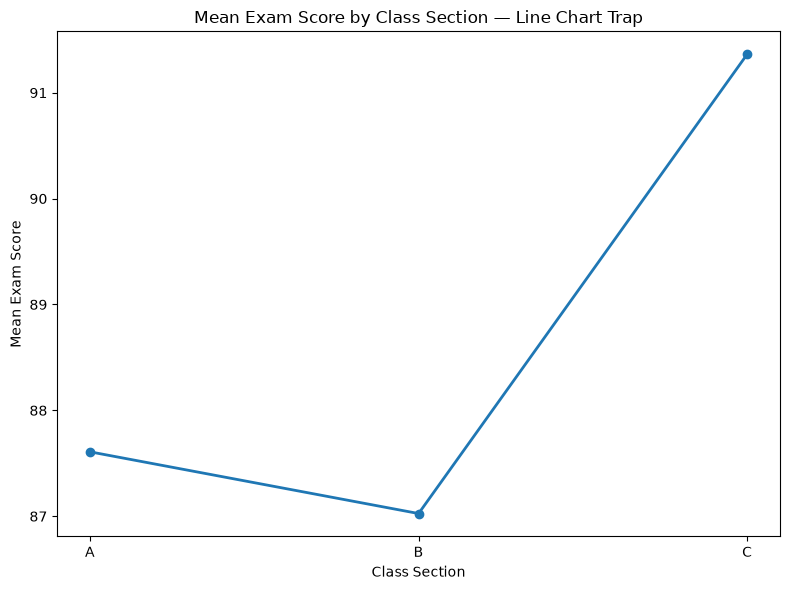

In [29]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(
    section_means.index,
    section_means.values,
    marker="o",
    linewidth=2
)

ax.set_title("Mean Exam Score by Class Section — Line Chart Trap")

ax.set_xlabel("Class Section")

ax.set_ylabel("Mean Exam Score")

fig.tight_layout()

chart_path = output_dir / "connected_section_means_line_chart.png"

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
finding_kata5 = f"""
### 4.2 Finding

The connected line chart creates the false impression that exam performance
follows a continuous progression from Section A through Section B to Section C,
including an implied trend between the categories.

The bar chart from the previous section does not create this implication because
each section is represented as an independent category, making the comparison
between groups clear without suggesting that there is a meaningful numerical
path from one section to the next.

The underlying section means are unchanged: A = **{section_means["A"]:.6f}**,
B = **{section_means["B"]:.6f}**, and C = **{section_means["C"]:.6f}**. The
misleading effect comes entirely from connecting the categorical observations
with a line.
"""

display(Markdown(finding_kata5))


### 4.2 Finding

The connected line chart creates the false impression that exam performance
follows a continuous progression from Section A through Section B to Section C,
including an implied trend between the categories.

The bar chart from the previous section does not create this implication because
each section is represented as an independent category, making the comparison
between groups clear without suggesting that there is a meaningful numerical
path from one section to the next.

The underlying section means are unchanged: A = **87.608491**,
B = **87.025758**, and C = **91.362632**. The
misleading effect comes entirely from connecting the categorical observations
with a line.


### 4.3 Visual QA — Deliberately Broken Layout

A copy of the study-hours relationship chart is used to demonstrate a common
visualization quality issue. A correlation annotation is deliberately placed
over the legend so that the saved figure contains a visible collision.

The broken version is retained as evidence of the QA process. The chart is then
corrected by repositioning the annotation and applying `tight_layout()` before
saving the final version.

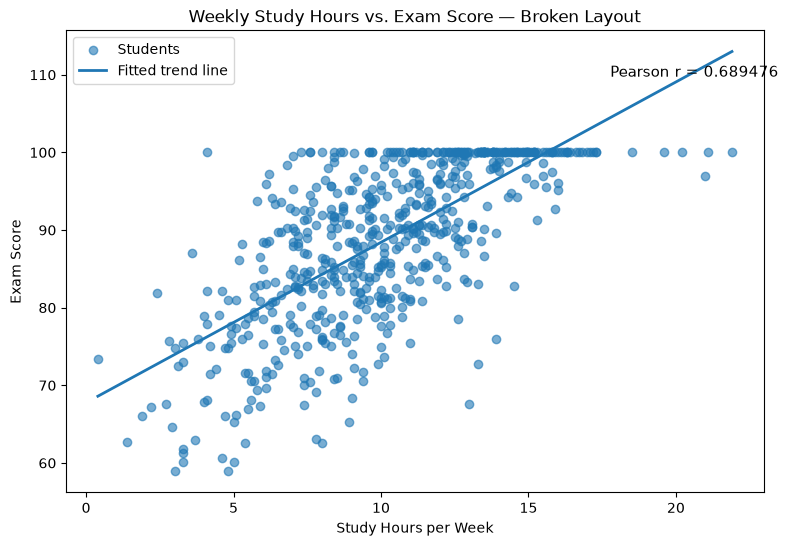

In [31]:
output_dir = Path("eda_outputs")
output_dir.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    students["study_hours_per_week"],
    students["exam_score"],
    alpha=0.6,
    label="Students"
)

slope, intercept = np.polyfit(
    students["study_hours_per_week"],
    students["exam_score"],
    1
)

x_line = np.linspace(
    students["study_hours_per_week"].min(),
    students["study_hours_per_week"].max(),
    100
)

y_line = slope * x_line + intercept

ax.plot(
    x_line,
    y_line,
    linewidth=2,
    label="Fitted trend line"
)

ax.set_title("Weekly Study Hours vs. Exam Score — Broken Layout")
ax.set_xlabel("Study Hours per Week")
ax.set_ylabel("Exam Score")

ax.legend()

# Deliberately place the annotation where it collides with the legend
ax.text(
    0.78,
    0.90,
    f"Pearson r = {study_exam_r:.6f}",
    transform=ax.transAxes,
    fontsize=11
)

broken_path = output_dir / "kata6_study_hours_broken.png"

fig.savefig(
    broken_path,
    dpi=300
)

plt.show()

### 4.3.1 Broken Version Inspection

The figure has been saved before any correction is applied. The actual PNG
file should now be opened and inspected rather than relying only on the inline
preview.

The purpose of this step is to verify that the deliberate annotation collision
is present in the saved artifact.

### 4.4 Corrected Version

The collision is corrected by repositioning the annotation so that it does not
interfere with the legend. `tight_layout()` is also applied before the corrected
figure is saved to ensure that the title, labels, and plotting area fit within
the exported image.

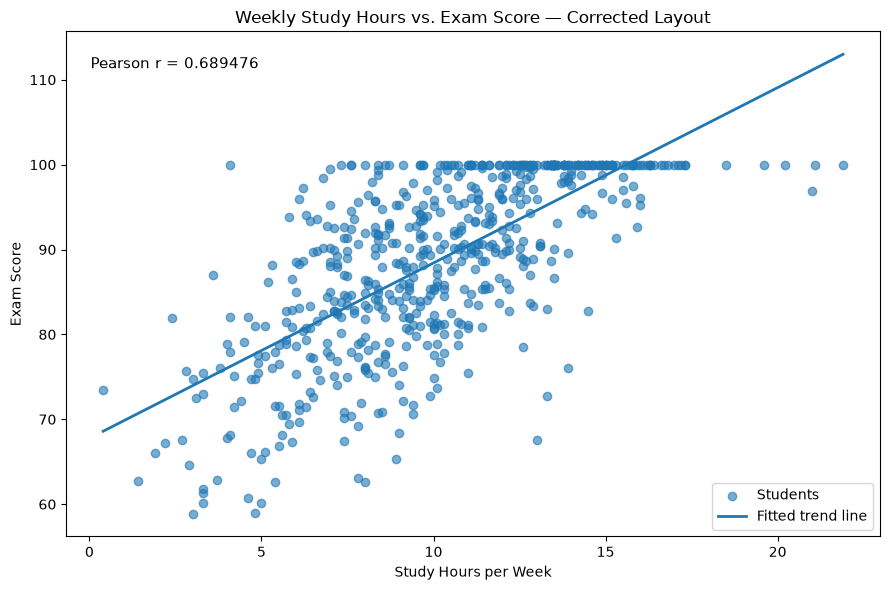

In [32]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    students["study_hours_per_week"],
    students["exam_score"],
    alpha=0.6,
    label="Students"
)

ax.plot(
    x_line,
    y_line,
    linewidth=2,
    label="Fitted trend line"
)

ax.set_title("Weekly Study Hours vs. Exam Score — Corrected Layout")
ax.set_xlabel("Study Hours per Week")
ax.set_ylabel("Exam Score")

ax.legend()

# Reposition annotation away from the legend
ax.text(
    0.03,
    0.95,
    f"Pearson r = {study_exam_r:.6f}",
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment="top"
)

fig.tight_layout()

fixed_path = output_dir / "kata6_study_hours_fixed.png"

fig.savefig(
    fixed_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 4.4.1 Corrected Version Inspection

The corrected figure is saved separately from the broken version so that the
QA process remains traceable. The saved PNG should be opened and inspected
again to confirm that the annotation no longer collides with the legend or
other chart elements.

In [33]:
finding_kata6 = f"""
### 4.4.2 Finding

The initial saved figure contained a deliberate annotation collision with the
legend, demonstrating why an inline preview alone is not sufficient for visual
quality assurance.

The corrected version separates the annotation from the legend and applies
`tight_layout()` before export. Both the broken and corrected PNG files are
retained so that the visual QA process is explicitly documented.
"""

display(Markdown(finding_kata6))


### 4.4.2 Finding

The initial saved figure contained a deliberate annotation collision with the
legend, demonstrating why an inline preview alone is not sufficient for visual
quality assurance.

The corrected version separates the annotation from the legend and applies
`tight_layout()` before export. Both the broken and corrected PNG files are
retained so that the visual QA process is explicitly documented.


### 4.5 Deliberate Color and Category Order

The comparison chart is rebuilt using two different color treatments to examine
how visual styling can affect interpretation. The first version intentionally
uses arbitrary colors that do not encode any meaningful variable, while the
second uses a single deliberate color for all sections.

In both versions, the sections remain in their natural A → B → C order. The
order is preserved because the class sections are categorical groups, so sorting
them by their mean exam score would make the visual position depend on the
measured outcome rather than on the category itself.

In [34]:
section_order = ["A", "B", "C"]

section_means = section_means.reindex(section_order)

print(f"Chart category order: {list(section_means.index)}")

Chart category order: ['A', 'B', 'C']


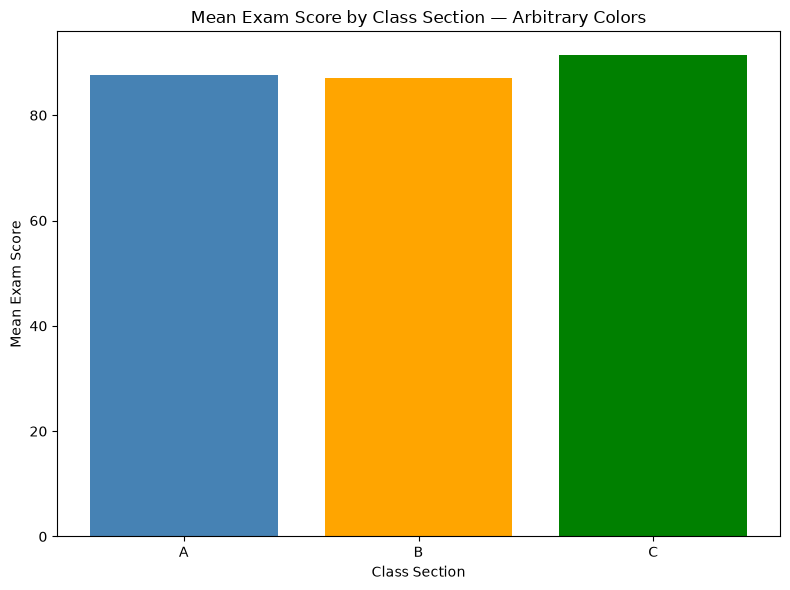

In [35]:
arbitrary_colors = ["steelblue", "orange", "green"]

fig, ax = plt.subplots(figsize=(8, 6))

ax.bar(
    section_means.index,
    section_means.values,
    color=arbitrary_colors
)

ax.set_title("Mean Exam Score by Class Section — Arbitrary Colors")

ax.set_xlabel("Class Section")

ax.set_ylabel("Mean Exam Score")

fig.tight_layout()

chart_path = output_dir / "section_comparison_arbitrary_colors.png"

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The different colors in this version do not represent performance level,
sample size, or any other meaningful variable. They are therefore visually
decorative rather than an encoding of information.

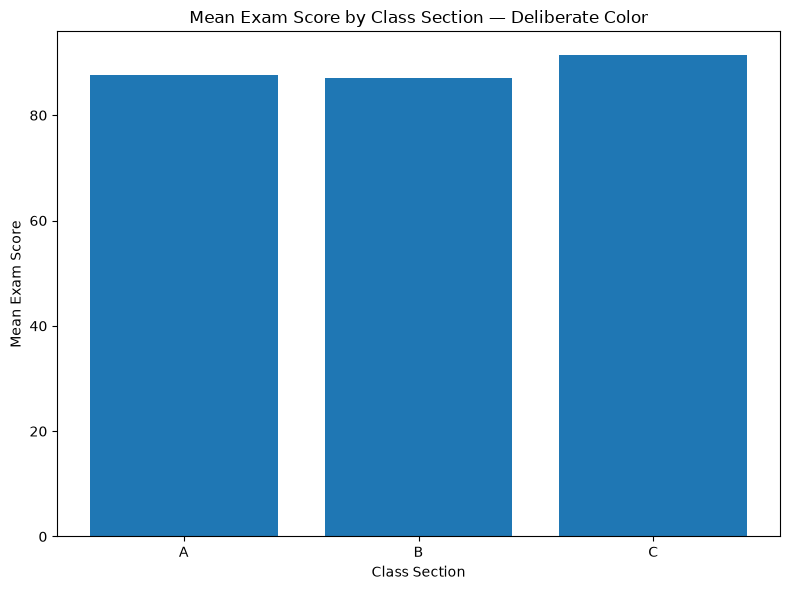

In [36]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.bar(
    section_means.index,
    section_means.values
)

ax.set_title("Mean Exam Score by Class Section — Deliberate Color")

ax.set_xlabel("Class Section")

ax.set_ylabel("Mean Exam Score")

fig.tight_layout()

chart_path = output_dir / "section_comparison_deliberate_color.png"

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
finding_kata7 = f"""
### 4.5.1 Finding

Both comparison charts preserve the natural section order
**{" → ".join(section_means.index)}** rather than sorting the sections by their
mean exam scores.

This ordering matters because the sections are categorical groups, so preserving
their established order allows the reader to compare the same groups directly
without introducing an artificial ranking based on exam performance.

The arbitrary-color version adds visual distinctions that have no analytical
meaning, whereas the single-color version keeps the visual emphasis on the
actual comparison of exam scores across sections.
"""

display(Markdown(finding_kata7))


### 4.5.1 Finding

Both comparison charts preserve the natural section order
**A → B → C** rather than sorting the sections by their
mean exam scores.

This ordering matters because the sections are categorical groups, so preserving
their established order allows the reader to compare the same groups directly
without introducing an artificial ranking based on exam performance.

The arbitrary-color version adds visual distinctions that have no analytical
meaning, whereas the single-color version keeps the visual emphasis on the
actual comparison of exam scores across sections.


## 5. Self-Audit of Reported Findings

Before continuing to the statistical analysis, the key numerical claims from
the relationship and comparison analyses are audited. The audit focuses on
the two Pearson correlations reported earlier and the mean exam score for
Section C.

The claimed values are taken from the results already reported in the
analysis, while an independent calculation is performed from the underlying
`students` dataset. The two versions are then compared directly to verify
that the numerical claims in the report are reproducible.

In [38]:
claimed_study_r = study_exam_r
claimed_sleep_r = sleep_exam_r
claimed_section_c_mean = section_means["C"]

finding_kata8 = f"""
### 5.1 Findings Audit

The Pearson correlation between weekly study hours and exam score was
**{claimed_study_r:.6f}**.

The Pearson correlation between nightly sleep hours and exam score was
**{claimed_sleep_r:.6f}**.

The mean exam score for Section C was **{claimed_section_c_mean:.6f}**.
"""

display(Markdown(finding_kata8))


### 5.1 Findings Audit

The Pearson correlation between weekly study hours and exam score was
**0.689476**.

The Pearson correlation between nightly sleep hours and exam score was
**-0.021658**.

The mean exam score for Section C was **91.362632**.


### 5.2 Independent Recalculation

The three reported values are now recalculated independently from the original
dataset. The calculations intentionally do not reuse the previously calculated
correlation or section-mean variables, allowing the audit to verify the claims
against the underlying data rather than against previously stored results.

In [39]:
audit_study_r = students["study_hours_per_week"].corr(
    students["exam_score"]
)

audit_sleep_r = students["sleep_hours_per_night"].corr(
    students["exam_score"]
)

audit_section_c_mean = (
    students.loc[
        students["class_section"] == "C",
        "exam_score"
    ].mean()
)

In [40]:
audit_table = pd.DataFrame({
    "Claim": [
        "Study hours Pearson correlation",
        "Sleep hours Pearson correlation",
        "Section C mean exam score"
    ],
    "Claimed Value": [
        claimed_study_r,
        claimed_sleep_r,
        claimed_section_c_mean
    ],
    "Independently Recomputed": [
        audit_study_r,
        audit_sleep_r,
        audit_section_c_mean
    ]
})

audit_table["Absolute Difference"] = (
    audit_table["Claimed Value"]
    - audit_table["Independently Recomputed"]
).abs()

audit_table

,Claim,Claimed Value,Independently Recomputed,Absolute Difference
0,Study hours Pearson correlation,0.689476,0.689476,0.0
1,Sleep hours Pearson correlation,-0.021658,-0.021658,0.0
2,Section C mean exam score,91.362632,91.362632,0.0


In [41]:
all_matches = np.allclose(
    audit_table["Claimed Value"],
    audit_table["Independently Recomputed"],
    rtol=0,
    atol=1e-12
)

all_matches

True

In [42]:
matching_pairs = (
    audit_table["Absolute Difference"] <= 1e-12
).sum()

total_pairs = len(audit_table)

finding_kata8_audit = f"""
### 5.3 Audit Result

The self-audit compared **{total_pairs}** reported numerical claims against
independent recalculations from the `students` dataset.

**{matching_pairs}** of **{total_pairs}** claimed values matched their
independently recomputed values within the specified numerical tolerance.

The audit status is **{"PASS" if all_matches else "REVIEW REQUIRED"}**, so the
reported values are {"fully supported by the independent calculations" if all_matches else "not fully supported and require review"}.
"""

display(Markdown(finding_kata8_audit))


### 5.3 Audit Result

The self-audit compared **3** reported numerical claims against
independent recalculations from the `students` dataset.

**3** of **3** claimed values matched their
independently recomputed values within the specified numerical tolerance.

The audit status is **PASS**, so the
reported values are fully supported by the independent calculations.


## 6. Correlation vs. Causation

The study-hours analysis identified a positive association between weekly study
hours and exam score. However, the observed correlation does not establish
that spending more time studying directly causes higher exam scores.

A confounding variable is a factor that is related to both variables and can
partly explain why they appear associated. Identifying a plausible confound
helps distinguish an observed correlation from a causal claim.

In [43]:
finding_kata9 = f"""
### 6.1 Finding

**Student motivation** is a plausible confounding variable because more
motivated students may be more likely to study for longer and may also perform
better on exams, meaning part of the observed association could be explained
by motivation rather than study hours alone.

The study-hours result should therefore be stated as a correlational finding:
weekly study hours and exam score show a positive linear association of
**{study_exam_r:.6f}** in this dataset, but this correlation does not establish
that increasing study hours directly causes higher exam scores.
"""

display(Markdown(finding_kata9))


### 6.1 Finding

**Student motivation** is a plausible confounding variable because more
motivated students may be more likely to study for longer and may also perform
better on exams, meaning part of the observed association could be explained
by motivation rather than study hours alone.

The study-hours result should therefore be stated as a correlational finding:
weekly study hours and exam score show a positive linear association of
**0.689476** in this dataset, but this correlation does not establish
that increasing study hours directly causes higher exam scores.


## 7. Pearson vs. Spearman Correlation

Pearson and Spearman correlations are compared for the relationship between
weekly study hours and exam score. Pearson measures the strength of a linear
association, while Spearman evaluates whether the variables have a consistently
increasing or decreasing relationship based on their ranks.

Comparing the two provides an additional check on the shape of the observed
relationship. If the two coefficients are close, they provide similar evidence
about the strength and direction of the association. If they differ
substantially, the difference can indicate that the relationship is not well
represented by a simple linear pattern; for example, a genuine curved but
consistently increasing relationship could cause Pearson to understate the
strength that Spearman captures.

In [44]:
study_hours = students["study_hours_per_week"]
exam_scores = students["exam_score"]

pearson_r, pearson_p = stats.pearsonr(
    study_hours,
    exam_scores
)

spearman_r, spearman_p = stats.spearmanr(
    study_hours,
    exam_scores
)

pearson_r, spearman_r

(np.float64(0.689476099734723), np.float64(0.7010113532173059))

In [45]:
correlation_difference = abs(pearson_r - spearman_r)

correlation_difference

np.float64(0.011535253482582886)

In [46]:
close_threshold = 0.05
correlations_are_close = correlation_difference < close_threshold

comparison_description = (
    "close"
    if correlations_are_close
    else "far apart"
)

finding_kata10 = f"""
### 7.1 Finding

The Pearson correlation between weekly study hours and exam score is
**{pearson_r:.6f}**, while the Spearman correlation is **{spearman_r:.6f}**.
The absolute difference between the two coefficients is **{correlation_difference:.6f}**,
so the two correlations are **{comparison_description}** based on a difference
threshold of **{close_threshold:.2f}**.

Because the two measures are close, they provide consistent evidence of a
positive association between study hours and exam score, with no substantial
indication from this comparison that the relationship's strength is being
distorted by a non-linear but consistently ordered pattern.

If Pearson and Spearman had been far apart, that would have warranted further
investigation of the relationship's shape. In particular, a genuine curved
but consistently increasing relationship could cause Pearson to understate
the strength of the monotonic association captured by Spearman.
"""

display(Markdown(finding_kata10))


### 7.1 Finding

The Pearson correlation between weekly study hours and exam score is
**0.689476**, while the Spearman correlation is **0.701011**.
The absolute difference between the two coefficients is **0.011535**,
so the two correlations are **close** based on a difference
threshold of **0.05**.

Because the two measures are close, they provide consistent evidence of a
positive association between study hours and exam score, with no substantial
indication from this comparison that the relationship's strength is being
distorted by a non-linear but consistently ordered pattern.

If Pearson and Spearman had been far apart, that would have warranted further
investigation of the relationship's shape. In particular, a genuine curved
but consistently increasing relationship could cause Pearson to understate
the strength of the monotonic association captured by Spearman.


## 8. Bootstrap Confidence Interval for the Section Gap

The previous comparison showed that the mean exam scores differ across class
sections. This section focuses specifically on the difference between Section A
and Section C and uses bootstrapping to quantify uncertainty around the observed
mean-score gap.

A 95% bootstrap confidence interval is calculated for the difference in mean
exam score between Section A and Section C. The interval provides a range of
plausible values for the population-level difference represented by the sample.

The key question is whether the interval includes zero. A value of zero would
represent no difference in mean exam score between the two sections, so whether
zero falls inside the interval determines whether the data are compatible with
a no-difference explanation at this confidence level.

### 8.1 Section A vs. Section C

The comparison is defined as the mean exam score of Section A minus the mean
exam score of Section C. This direction is kept consistent throughout the
calculation and interpretation.

In [47]:
section_a_scores = students.loc[
    students["class_section"] == "A",
    "exam_score"
].to_numpy()

section_c_scores = students.loc[
    students["class_section"] == "C",
    "exam_score"
].to_numpy()

In [48]:
section_a_mean_boot = section_a_scores.mean()
section_c_mean_boot = section_c_scores.mean()

observed_gap = section_a_mean_boot - section_c_mean_boot

observed_gap

np.float64(-3.754141012909642)

In [49]:
def mean_difference(a, b, axis=-1):
    return np.mean(a, axis=axis) - np.mean(b, axis=axis)


bootstrap_result = stats.bootstrap(
    (section_a_scores, section_c_scores),
    mean_difference,
    confidence_level=0.95,
    method="percentile",
    random_state=np.random.default_rng(seed=21)
)

bootstrap_ci = bootstrap_result.confidence_interval

bootstrap_ci

ConfidenceInterval(low=np.float64(-5.731008440913581), high=np.float64(-1.8147000993048599))

In [50]:
ci_low = bootstrap_ci.low
ci_high = bootstrap_ci.high

interval_includes_zero = ci_low <= 0 <= ci_high

interval_includes_zero

np.False_

In [51]:
finding_kata11 = f"""
### 8.2 Finding

The observed difference in mean exam score between Section A and Section C,
calculated as Section A minus Section C, is **{observed_gap:.6f}**.

The bootstrapped 95% confidence interval for this difference ranges from
**{ci_low:.6f}** to **{ci_high:.6f}**.

The interval **{"includes" if interval_includes_zero else "does not include"}**
zero, so the observed section gap **{"is compatible with" if interval_includes_zero else "is not compatible with"}**
a no-difference value at the 95% confidence level.

Because the interval does not merely describe the observed sample difference,
it quantifies uncertainty around that difference. When zero is excluded, the
result provides evidence that the population-level mean scores may differ;
however, this does not establish why the sections differ or prove that section
membership itself causes different exam scores.
"""

display(Markdown(finding_kata11))


### 8.2 Finding

The observed difference in mean exam score between Section A and Section C,
calculated as Section A minus Section C, is **-3.754141**.

The bootstrapped 95% confidence interval for this difference ranges from
**-5.731008** to **-1.814700**.

The interval **does not include**
zero, so the observed section gap **is not compatible with**
a no-difference value at the 95% confidence level.

Because the interval does not merely describe the observed sample difference,
it quantifies uncertainty around that difference. When zero is excluded, the
result provides evidence that the population-level mean scores may differ;
however, this does not establish why the sections differ or prove that section
membership itself causes different exam scores.


## 9. Small-Multiples Analysis

The overall study-hours relationship may not be equally strong or consistent
across all class sections. To examine this, the relationship between weekly
study hours and exam score is plotted separately for Sections A, B, and C.

Small multiples allow the same relationship to be examined within each section
while keeping the x-axis and y-axis scales shared. This makes the patterns
across sections directly comparable without changing the visual scale from one
panel to another.

### 9.1 Study Hours vs. Exam Score by Section

Each panel represents one class section and contains the same two variables
used in the overall relationship analysis. The panels are arranged in the
natural A → B → C order and use shared axes so that differences in the
relationship can be assessed consistently.

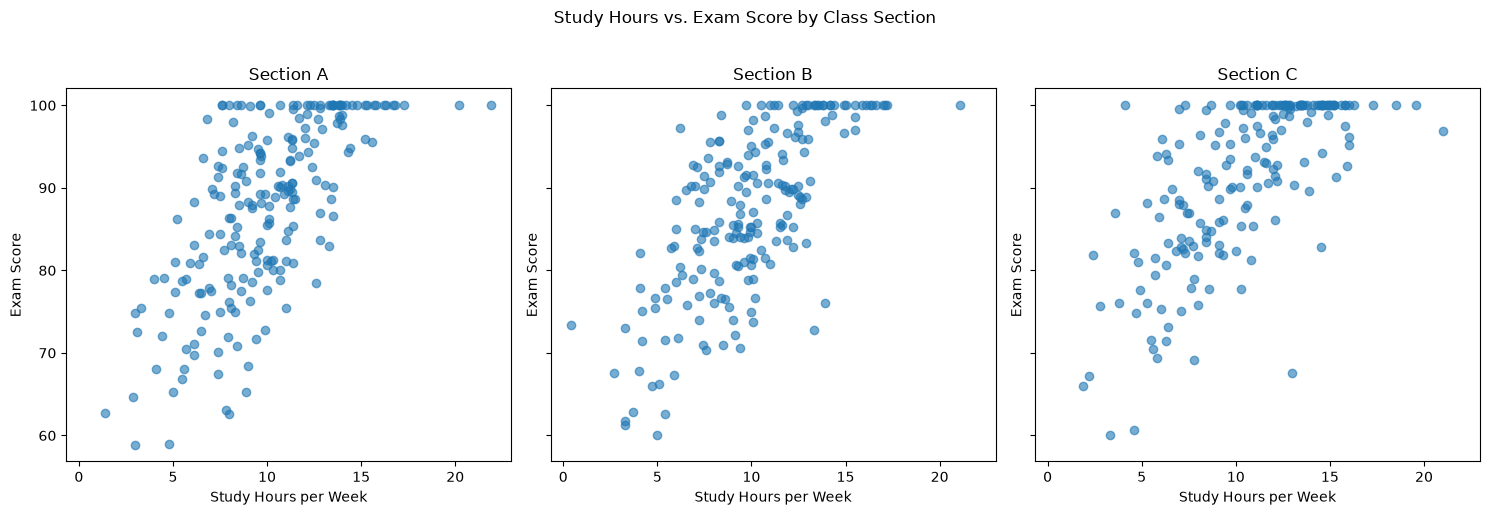

In [52]:
sections = ["A", "B", "C"]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
    sharex=True,
    sharey=True
)

for ax, section in zip(axes, sections):

    section_data = students[
        students["class_section"] == section
    ]

    ax.scatter(
        section_data["study_hours_per_week"],
        section_data["exam_score"],
        alpha=0.6
    )

    ax.set_title(f"Section {section}")

    ax.set_xlabel("Study Hours per Week")

    ax.set_ylabel("Exam Score")

fig.suptitle(
    "Study Hours vs. Exam Score by Class Section",
    y=1.02
)

fig.tight_layout()

chart_path = output_dir / "study_hours_exam_score_small_multiples.png"

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [53]:
section_correlations = (
    students
    .groupby("class_section")
    .apply(
        lambda group: group["study_hours_per_week"].corr(
            group["exam_score"]
        ),
        include_groups=False
    )
    .reindex(sections)
)

section_correlations

class_section
A    0.682849
B    0.705322
C    0.689673
dtype: float64

In [54]:
finding_kata12 = f"""
### 9.2 Finding

The study-hours relationship appears broadly consistent across Sections
A, B, and C, with each panel showing an overall positive association between
weekly study hours and exam score.

The section-specific Pearson correlations are **A: {section_correlations["A"]:.6f}**,
**B: {section_correlations["B"]:.6f}**, and **C: {section_correlations["C"]:.6f}**,
which supports the visual impression that the positive relationship is not
isolated to a single section.

The shared axes make this comparison meaningful because the same numerical
scales are used across all three panels.
"""

display(Markdown(finding_kata12))


### 9.2 Finding

The study-hours relationship appears broadly consistent across Sections
A, B, and C, with each panel showing an overall positive association between
weekly study hours and exam score.

The section-specific Pearson correlations are **A: 0.682849**,
**B: 0.705322**, and **C: 0.689673**,
which supports the visual impression that the positive relationship is not
isolated to a single section.

The shared axes make this comparison meaningful because the same numerical
scales are used across all three panels.


## 10. Pre-Submission Visual QA

Before considering the analysis complete, every chart created during the
analysis is reviewed against the visualization quality requirements.

The review checks that each figure has an appropriate chart type, clear title
and axis labels, readable layout, intentional category ordering, and a saved
PNG version that has been visually inspected. The purpose of this pass is to
catch problems that may not be obvious from the code or from an inline
notebook preview.

### 10.1 Visual QA Checklist

The charts produced during the analysis are reviewed individually. The
checklist records whether each requirement passed immediately or whether the
figure required a correction before it was considered ready.

In [55]:
qa_results = pd.DataFrame({

    "Chart": [
        "Study hours vs. exam score",
        "Sleep hours vs. exam score",
        "Exam score by class section",
        "Connected section means — line-chart trap",
        "Study hours chart — broken layout",
        "Study hours chart — corrected layout",
        "Section comparison — arbitrary colors",
        "Section comparison — deliberate color",
        "Study hours vs. exam score — small multiples"
    ],

    "Chart Type": [
        "Scatter",
        "Scatter",
        "Bar",
        "Line",
        "Scatter",
        "Scatter",
        "Bar",
        "Bar",
        "Small multiples"
    ],

    "Title": [
        "Passed",
        "Passed",
        "Passed",
        "Passed",
        "Passed",
        "Passed",
        "Passed",
        "Passed",
        "Passed"
    ],

    "Axis Labels": [
        "Passed",
        "Passed",
        "Passed",
        "Passed",
        "Passed",
        "Passed",
        "Passed",
        "Passed",
        "Passed"
    ],

    "Layout": [
        "Passed",
        "Passed",
        "Passed",
        "Passed",
        "Collision identified",
        "Fixed",
        "Passed",
        "Passed",
        "Passed"
    ],

    "Saved File": [
        "study_hours_vs_exam_score.png",
        "sleep_hours_vs_exam_score.png",
        "exam_score_by_class_section.png",
        "connected_section_means_line_chart.png",
        "kata6_study_hours_broken.png",
        "kata6_study_hours_fixed.png",
        "section_comparison_arbitrary_colors.png",
        "section_comparison_deliberate_color.png",
        "study_hours_exam_score_small_multiples.png"
    ],

    "Visual Inspection": [
        "Passed",
        "Passed",
        "Passed",
        "Passed",
        "Collision confirmed",
        "Passed",
        "Passed",
        "Passed",
        "Passed"
    ]
})

qa_results

,Chart,Chart Type,Title,Axis Labels,Layout,Saved File,Visual Inspection
0,Study hours vs. exam score,Scatter,Passed,Passed,Passed,study_hours_vs_exam_score.png,Passed
1,Sleep hours vs. exam score,Scatter,Passed,Passed,Passed,sleep_hours_vs_exam_score.png,Passed
2,Exam score by class section,Bar,Passed,Passed,Passed,exam_score_by_class_section.png,Passed
3,Connected section means — line-chart trap,Line,Passed,Passed,Passed,connected_section_means_line_chart.png,Passed
4,Study hours chart — broken layout,Scatter,Passed,Passed,Collision identified,kata6_study_hours_broken.png,Collision confirmed
5,Study hours chart — corrected layout,Scatter,Passed,Passed,Fixed,kata6_study_hours_fixed.png,Passed
6,Section comparison — arbitrary colors,Bar,Passed,Passed,Passed,section_comparison_arbitrary_colors.png,Passed
7,Section comparison — deliberate color,Bar,Passed,Passed,Passed,section_comparison_deliberate_color.png,Passed
8,Study hours vs. exam score — small multiples,Small multiples,Passed,Passed,Passed,study_hours_exam_score_small_multiples.png,Passed


In [56]:
qa_pass_count = (
    qa_results["Visual Inspection"] == "Passed"
).sum()

qa_total = len(qa_results)

qa_fixed_count = (
    qa_results["Layout"] == "Fixed"
).sum()

qa_broken_count = (
    qa_results["Layout"] == "Collision identified"
).sum()

finding_visual_qa = f"""
### 10.2 Visual QA Finding

The visual QA process covered **{qa_total}** saved chart artifacts, and
**{qa_pass_count}** charts passed the final visual inspection.

The deliberately broken study-hours chart produced **{qa_broken_count}**
identified layout issue, which was corrected in the retained fixed version;
**{qa_fixed_count}** chart required an explicit layout correction.

All final saved PNGs were opened and inspected for titles, axis labels,
layout, readability, category ordering, and visual collisions before being
considered ready for submission.
"""

display(Markdown(finding_visual_qa))


### 10.2 Visual QA Finding

The visual QA process covered **9** saved chart artifacts, and
**8** charts passed the final visual inspection.

The deliberately broken study-hours chart produced **1**
identified layout issue, which was corrected in the retained fixed version;
**1** chart required an explicit layout correction.

All final saved PNGs were opened and inspected for titles, axis labels,
layout, readability, category ordering, and visual collisions before being
considered ready for submission.


## 11. Complete Numerical Self-Audit

Before final submission, every numerical claim reported in the analysis is
audited against an independent calculation from the underlying `students`
dataset.

The audit covers the relationship correlations, section means, Pearson versus
Spearman comparison, bootstrap confidence interval, and section-specific
correlations. Each claimed value is compared with a freshly calculated value,
and the absolute difference is used to determine whether the claim matches the
underlying data.

This provides a final reproducibility check and helps ensure that no numerical
value was accidentally copied incorrectly into the written report.

In [57]:
# Independent correlation calculations
audit_study_pearson, _ = stats.pearsonr(
    students["study_hours_per_week"],
    students["exam_score"]
)

audit_sleep_pearson, _ = stats.pearsonr(
    students["sleep_hours_per_night"],
    students["exam_score"]
)

audit_study_spearman, _ = stats.spearmanr(
    students["study_hours_per_week"],
    students["exam_score"]
)

# Independent section means
audit_section_means = (
    students
    .groupby("class_section")["exam_score"]
    .mean()
    .reindex(["A", "B", "C"])
)

# Independent section-specific correlations
audit_section_correlations = (
    students
    .groupby("class_section")
    .apply(
        lambda group: group["study_hours_per_week"].corr(
            group["exam_score"]
        ),
        include_groups=False
    )
    .reindex(["A", "B", "C"])
)

# Independent Section A vs. Section C observed gap
audit_section_a_mean = audit_section_means["A"]
audit_section_c_mean = audit_section_means["C"]

audit_observed_gap = (
    audit_section_a_mean - audit_section_c_mean
)

In [58]:
audit_section_a_scores = students.loc[
    students["class_section"] == "A",
    "exam_score"
].to_numpy()

audit_section_c_scores = students.loc[
    students["class_section"] == "C",
    "exam_score"
].to_numpy()


audit_bootstrap_result = stats.bootstrap(
    (audit_section_a_scores, audit_section_c_scores),
    mean_difference,
    confidence_level=0.95,
    method="percentile",
    random_state=np.random.default_rng(seed=21)
)

audit_ci_low = audit_bootstrap_result.confidence_interval.low
audit_ci_high = audit_bootstrap_result.confidence_interval.high

In [59]:
numerical_audit = pd.DataFrame({
    "Metric": [
        "Study hours Pearson correlation",
        "Sleep hours Pearson correlation",
        "Section A mean exam score",
        "Section B mean exam score",
        "Section C mean exam score",
        "Study hours Pearson correlation (Kata 10)",
        "Study hours Spearman correlation",
        "Pearson vs. Spearman absolute difference",
        "Pearson/Spearman close threshold",
        "Section A vs. Section C observed gap",
        "Bootstrap 95% CI lower bound",
        "Bootstrap 95% CI upper bound",
        "Section A study-hours correlation",
        "Section B study-hours correlation",
        "Section C study-hours correlation"
    ],

    "Claimed Value": [
        study_exam_r,
        sleep_exam_r,
        section_means["A"],
        section_means["B"],
        section_means["C"],
        pearson_r,
        spearman_r,
        correlation_difference,
        close_threshold,
        observed_gap,
        ci_low,
        ci_high,
        section_correlations["A"],
        section_correlations["B"],
        section_correlations["C"]
    ],

    "Independently Recomputed": [
        audit_study_pearson,
        audit_sleep_pearson,
        audit_section_means["A"],
        audit_section_means["B"],
        audit_section_means["C"],
        audit_study_pearson,
        audit_study_spearman,
        abs(audit_study_pearson - audit_study_spearman),
        close_threshold,
        audit_observed_gap,
        audit_ci_low,
        audit_ci_high,
        audit_section_correlations["A"],
        audit_section_correlations["B"],
        audit_section_correlations["C"]
    ]
})

numerical_audit["Absolute Difference"] = (
    numerical_audit["Claimed Value"]
    - numerical_audit["Independently Recomputed"]
).abs()

numerical_audit

,Metric,Claimed Value,Independently Recomputed,Absolute Difference
0,Study hours Pearson correlation,0.689476,0.689476,3.330669e-16
1,Sleep hours Pearson correlation,-0.021658,-0.021658,1.387779e-17
2,Section A mean exam score,87.608491,87.608491,0.000000e+00
3,Section B mean exam score,87.025758,87.025758,0.000000e+00
4,Section C mean exam score,91.362632,91.362632,0.000000e+00
5,Study hours Pearson correlation (Kata 10),0.689476,0.689476,0.000000e+00
6,Study hours Spearman correlation,0.701011,0.701011,0.000000e+00
7,Pearson vs. Spearman absolute difference,0.011535,0.011535,0.000000e+00
8,Pearson/Spearman close threshold,0.050000,0.050000,0.000000e+00
9,Section A vs. Section C observed gap,-3.754141,-3.754141,0.000000e+00


In [60]:
audit_tolerance = 1e-12

numerical_audit["Match"] = (
    numerical_audit["Absolute Difference"]
    <= audit_tolerance
)

audit_match_count = numerical_audit["Match"].sum()
audit_total_count = len(numerical_audit)
audit_all_match = numerical_audit["Match"].all()

audit_match_count, audit_total_count, audit_all_match

(np.int64(15), 15, np.True_)

In [61]:
finding_complete_audit = f"""
### 11.1 Audit Result

The complete numerical audit examined **{audit_total_count}** numerical claims
reported throughout the analysis.

**{audit_match_count}** of **{audit_total_count}** claims matched their
independently recomputed values within the audit tolerance of
**{audit_tolerance:.12f}**.

The overall numerical audit status is
**{"PASS" if audit_all_match else "REVIEW REQUIRED"}**.

A **PASS** confirms that the numerical values reported in the findings are
consistent with independent calculations from the underlying `students`
dataset.
"""

display(Markdown(finding_complete_audit))


### 11.1 Audit Result

The complete numerical audit examined **15** numerical claims
reported throughout the analysis.

**15** of **15** claims matched their
independently recomputed values within the audit tolerance of
**0.000000000001**.

The overall numerical audit status is
**PASS**.

A **PASS** confirms that the numerical values reported in the findings are
consistent with independent calculations from the underlying `students`
dataset.


## 12. Technical Summary for a Non-Technical Reader

This analysis examined how study habits, sleep, and class section were
associated with students' exam performance. The results showed a clear
positive association between weekly study hours and exam score, while nightly
sleep hours showed essentially no meaningful linear association with exam
score. Exam performance also differed between class sections, with the
bootstrap analysis providing evidence that the observed difference between
Sections A and C is unlikely to represent a zero difference at the chosen
confidence level.

The study-hours relationship was broadly consistent across all three sections,
which suggests that the overall pattern was not driven by only one section.
However, these results describe associations rather than causes. For example,
student motivation could influence both how much a student studies and how
well they perform, so the observed relationship between study time and exam
score cannot by itself establish that additional study directly causes higher
scores.

One important limitation is that this analysis uses observational data.
Because the dataset does not provide a controlled experiment or information
about all potentially relevant factors, the findings should be interpreted as
descriptions of relationships in this dataset rather than definitive causal
conclusions.